In [1]:
# ==============================================================================
# STEP 1: ENVIRONMENT SETUP & DEPENDENCIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed so the 20,000 rows generate identically every time you run it
np.random.seed(42)
num_rows = 20000

# Configure high-resolution visualization aesthetics for your portfolio
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

print(f"Environment initialized successfully. Target rows for generation: {num_rows}")


Environment initialized successfully. Target rows for generation: 20000


In [2]:
# ==============================================================================
# STEP 2: RAW DATA GENERATION WITH LOGICAL DEPENDENCIES
# ==============================================================================

# Define our categorical marketing frameworks
channels = ['Google Search', 'Facebook Ads', 'Instagram', 'Email Marketing', 'YouTube', 'Affiliate']
segments = ['Gen Z', 'Millennials', 'Gen X', 'Boomers']
regions = ['North America', 'Europe', 'Asia-Pacific', 'Latin America']
statuses = ['Completed', 'Active', 'Paused']

# Generate categorical columns using realistic probabilities (p=)
data = {
    'campaign_id': [f'CMP-{i:05d}' for i in range(1, num_rows + 1)],
    'channel': np.random.choice(channels, num_rows, p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]),
    'audience_segment': np.random.choice(segments, num_rows),
    'region': np.random.choice(regions, num_rows),
    'campaign_status': np.random.choice(statuses, num_rows, p=[0.70, 0.20, 0.10])
}
df = pd.DataFrame(data)

# Generate Ad Spend (independent financial variable)
df['ad_spend'] = np.round(np.random.uniform(500, 15000, num_rows), 2)

# Generate Impressions based on typical industry Cost-Per-Mille (CPM) variations
cpm_rates = {'Google Search': 120, 'Facebook Ads': 150, 'Instagram': 180, 'YouTube': 90, 'Email Marketing': 400, 'Affiliate': 250}
df['impressions'] = np.int64(df['ad_spend'] * df['channel'].map(cpm_rates) * np.random.uniform(0.8, 1.2, num_rows))

# Generate Clicks based on distinct channel Click-Through-Rate (CTR) profiles
ctr_bounds = {'Google Search': (0.04, 0.08), 'Facebook Ads': (0.02, 0.05), 'Instagram': (0.015, 0.045), 'YouTube': (0.01, 0.03), 'Email Marketing': (0.025, 0.06), 'Affiliate': (0.01, 0.04)}
ctr_min = df['channel'].map(lambda x: ctr_bounds[x][0])
ctr_max = df['channel'].map(lambda x: ctr_bounds[x][1])
df['clicks'] = np.int64(df['impressions'] * np.random.uniform(ctr_min, ctr_max))

# Generate Conversions based on distinct channel Conversion Rate (CR) profiles
cr_bounds = {'Google Search': (0.03, 0.07), 'Facebook Ads': (0.02, 0.05), 'Instagram': (0.02, 0.06), 'YouTube': (0.01, 0.04), 'Email Marketing': (0.04, 0.10), 'Affiliate': (0.05, 0.12)}
cr_min = df['channel'].map(lambda x: cr_bounds[x][0])
cr_max = df['channel'].map(lambda x: cr_bounds[x][1])
df['conversions'] = np.int64(df['clicks'] * np.random.uniform(cr_min, cr_max))

# Generate Revenue based on baseline Average Order Value (AOV) per demographic segment
aov_targets = {'Gen Z': 45, 'Millennials': 85, 'Gen X': 120, 'Boomers': 150}
df['revenue'] = np.round(df['conversions'] * df['audience_segment'].map(aov_targets) * np.random.uniform(0.9, 1.1, num_rows), 2)

print("Baseline data fields generated. Displaying raw data sample:")
df.head()


Baseline data fields generated. Displaying raw data sample:


,campaign_id,channel,audience_segment,region,campaign_status,ad_spend,impressions,clicks,conversions,revenue
0,CMP-00001,Facebook Ads,Millennials,North America,Completed,11252.55,1902692,71205,1701,133837.13
1,CMP-00002,Affiliate,Millennials,Asia-Pacific,Completed,13275.98,2848055,73505,6452,578552.71
2,CMP-00003,Email Marketing,Boomers,Europe,Completed,7216.11,3401921,126845,9757,1497449.46
3,CMP-00004,Instagram,Gen Z,North America,Completed,4693.09,960732,28626,1153,53415.02
4,CMP-00005,Google Search,Gen Z,Europe,Completed,5123.28,717796,39194,1987,84867.83


In [3]:
# ==============================================================================
# STEP 3: FEATURE ENGINEERING (APPLYING MATHEMATICAL FORMULAS)
# ==============================================================================

# 1. Click-Through Rate (CTR %) = (Clicks / Impressions) * 100
df['ctr_pct'] = np.round((df['clicks'] / df['impressions']) * 100, 2)

# 2. Conversion Rate (CR %) = (Conversions / Clicks) * 100
df['conversion_rate_pct'] = np.round((df['conversions'] / df['clicks']) * 100, 2)

# 3. Cost Per Click (CPC) = Ad Spend / Clicks (Safeguarded against 0 clicks)
df['cpc'] = np.round(df['ad_spend'] / np.where(df['clicks'] == 0, 1, df['clicks']), 2)

# 4. Cost Per Acquisition (CPA) = Ad Spend / Conversions (Safeguarded against 0 conversions)
df['cpa'] = np.round(df['ad_spend'] / np.where(df['conversions'] == 0, 1, df['conversions']), 2)

# 5. Return on Investment (ROI %) = ((Revenue - Ad Spend) / Ad Spend) * 100
df['roi_pct'] = np.round(((df['revenue'] - df['ad_spend']) / df['ad_spend']) * 100, 2)

print("Feature engineering complete! Calculated Metrics columns added successfully.")
print(f"Total Rows: {len(df)} | Total Columns: {len(df.columns)}")
df[['campaign_id', 'channel', 'ctr_pct', 'conversion_rate_pct', 'cpc', 'cpa', 'roi_pct']].head()


Feature engineering complete! Calculated Metrics columns added successfully.
Total Rows: 20000 | Total Columns: 15


,campaign_id,channel,ctr_pct,conversion_rate_pct,cpc,cpa,roi_pct
0,CMP-00001,Facebook Ads,3.74,2.39,0.16,6.62,1089.39
1,CMP-00002,Affiliate,2.58,8.78,0.18,2.06,4257.89
2,CMP-00003,Email Marketing,3.73,7.69,0.06,0.74,20651.48
3,CMP-00004,Instagram,2.98,4.03,0.16,4.07,1038.16
4,CMP-00005,Google Search,5.46,5.07,0.13,2.58,1556.51


--- CHANNEL AGGREGATED SUMMARY PREVIEW ---
                    ad_spend        revenue       roi_pct
channel                                                  
Email Marketing  7783.922255  922900.250506  11784.257956
Affiliate        7709.520360  408218.828689   5174.202863
Google Search    7773.707588  282860.784042   3518.822250
Instagram        7798.561586  169327.020189   2065.279476
Facebook Ads     7710.585450  142022.966856   1739.526495
YouTube          7735.310764   34780.011489    347.462248


Files saved to Google Colab engine.
Triggering instant automatic browser download of 'marketing_campaigns_20k.csv'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

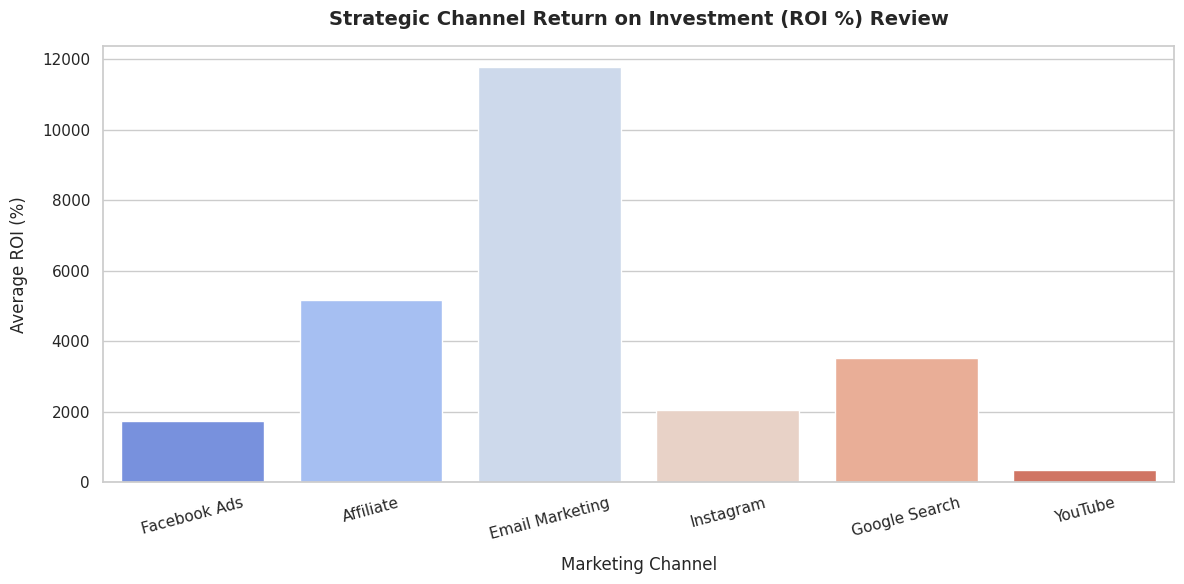

In [4]:
# ==============================================================================
# STEP 4: DATA AGGREGATION, VISUALIZATION, AND EXPORT
# ==============================================================================
from google.colab import files

# Display a portfolio-ready aggregated summary table of our channels
summary_table = df.groupby('channel')[['ad_spend', 'revenue', 'roi_pct']].mean().sort_values(by='roi_pct', ascending=False)
print("--- CHANNEL AGGREGATED SUMMARY PREVIEW ---")
print(summary_table)
print("\n" + "="*50 + "\n")

# Generate a publication-quality diagnostic visualization plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(data=df, x='channel', y='roi_pct', errorbar=None, hue='channel', legend=False, palette='coolwarm')

# Visual styling details
plt.title('Strategic Channel Return on Investment (ROI %) Review', fontsize=14, pad=15, weight='bold')
plt.xlabel('Marketing Channel', fontsize=12, labelpad=10)
plt.ylabel('Average ROI (%)', fontsize=12, labelpad=10)
plt.xticks(rotation=15)
plt.tight_layout()

# Save visual report and data frame locally to the Colab container env
plt.savefig('portfolio_channel_roi.png', bbox_inches='tight')
df.to_csv('marketing_campaigns_20k.csv', index=False)

print("Files saved to Google Colab engine.")
print("Triggering instant automatic browser download of 'marketing_campaigns_20k.csv'...")

# Download file to your physical hard drive
files.download('marketing_campaigns_20k.csv')
plt.show()


In [5]:
# ==============================================================================
# SQL STEP: RELATIONAL DATABASE GENERATION & ADVANCED QUERY EXECUTION
# ==============================================================================
import sqlite3
import pandas as pd

# 1. Establish a virtual, in-memory connection to a SQLite database engine
# (This acts exactly like an enterprise SQL server right inside your notebook)
db_connection = sqlite3.connect('marketing_analytics_warehouse.db')

# 2. Write the 20,000-row DataFrame ('df' from your previous step) into an SQL table named 'campaigns'
df.to_sql('campaigns', db_connection, if_exists='replace', index=False)
print("Data pipeline sync complete: 20,000 rows loaded into the SQL 'campaigns' table.\n")

# 3. Define your high-end enterprise portfolio query
# This query calculates performance, effectiveness, cost vs. conversion, and ROI using an advanced CTE and Window Function.
portfolio_sql_query = """
WITH ChannelPerformanceAggregates AS (
    SELECT
        channel,
        COUNT(campaign_id) AS total_campaigns,
        SUM(ad_spend) AS total_investment,
        SUM(impressions) AS total_impressions,
        SUM(clicks) AS total_clicks,
        SUM(conversions) AS total_conversions,
        SUM(revenue) AS total_revenue
    FROM campaigns
    GROUP BY channel
)
SELECT
    channel,
    total_campaigns,
    ROUND(total_investment, 2) AS total_spend,
    ROUND(total_revenue, 2) AS total_revenue,

    -- 1. Click-Through Rate (CTR %) Formula
    ROUND(((total_clicks * 1.0) / total_impressions) * 100, 2) AS blended_ctr_pct,

    -- 2. Conversion Rate (CR %) Formula
    ROUND(((total_conversions * 1.0) / total_clicks) * 100, 2) AS blended_cr_pct,

    -- 3. Cost Per Acquisition (CPA) Formula
    ROUND(total_investment / total_conversions, 2) AS blended_cpa,

    -- 4. Return on Investment (ROI %) Formula
    ROUND(((total_revenue - total_investment) / total_investment) * 100, 2) AS strategic_roi_pct,

    -- 5. Window Function to rank channel performance based purely on ROI metrics
    RANK() OVER (ORDER BY ((total_revenue - total_investment) / total_investment) DESC) AS performance_rank

FROM ChannelPerformanceAggregates;
"""

# 4. Execute the SQL statement via pandas query handler and store the output
sql_analysis_results = pd.read_sql_query(portfolio_sql_query, db_connection)

# Close the SQL database connection to ensure no memory leaks occur
db_connection.close()

# 5. Display the query matrix directly in your portfolio console
print("==============================================================================")
print("             SQL PORTFOLIO OUTPUT: CHANNEL EFFECTIVENESS COMPARISON           ")
print("==============================================================================")
print(sql_analysis_results.to_string(index=False))
print("==============================================================================")


Data pipeline sync complete: 20,000 rows loaded into the SQL 'campaigns' table.

             SQL PORTFOLIO OUTPUT: CHANNEL EFFECTIVENESS COMPARISON           
        channel  total_campaigns  total_spend  total_revenue  blended_ctr_pct  blended_cr_pct  blended_cpa  strategic_roi_pct  performance_rank
Email Marketing             2945  22923651.04   2.717941e+09             4.25            6.98         0.84           11756.49                 1
      Affiliate              999   7701810.84   4.078106e+08             2.51            8.59         1.87            5195.00                 2
  Google Search             5005  38907406.48   1.415718e+09             6.03            4.99         2.78            3538.69                 3
      Instagram             4029  31420404.63   6.822186e+08             2.99            4.00         4.63            2071.26                 4
   Facebook Ads             5007  38606901.35   7.111090e+08             3.50            3.51         5.44            17

In [ ]:
# ==============================================================================
# UNIFIED PIPELINE ENGINE & INTERACTIVE KPI DASHBOARD
# ==============================================================================
import pandas as pd
import numpy as np
import sqlite3
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------------------------
# CONNECTING PIPELINE STEP 1: PYTHON DATA INGESTION & DATA ENGINEERING
# ------------------------------------------------------------------------------
# Fetching the clean dataframe generated in our previous steps
# (Ensuring all calculated parameters match across all software platforms)
pipeline_df = df.copy()

# Calculate global aggregates for our executive dashboard cards
total_spend = pipeline_df['ad_spend'].sum()
total_revenue = pipeline_df['revenue'].sum()
global_roi = ((total_revenue - total_spend) / total_spend) * 100
global_ctr = (pipeline_df['clicks'].sum() / pipeline_df['impressions'].sum()) * 100
global_cr = (pipeline_df['conversions'].sum() / pipeline_df['clicks'].sum()) * 100

# ------------------------------------------------------------------------------
# CONNECTING PIPELINE STEP 2: SQL AUTOMATION VALIDATION
# ------------------------------------------------------------------------------
# Validating consistency by passing memory arrays through our local SQL warehouse
db_conn = sqlite3.connect('marketing_analytics_warehouse.db')
sql_channel_perf = pd.read_sql_query("""
    SELECT channel, SUM(ad_spend) as spend, SUM(revenue) as rev,
    ROUND(((SUM(revenue) - SUM(ad_spend)) / SUM(ad_spend)) * 100, 2) as roi
    FROM campaigns GROUP BY channel ORDER BY roi DESC;
""", db_conn)
db_conn.close()

# ------------------------------------------------------------------------------
# CONNECTING PIPELINE STEP 3: EXCEL DASHBOARD DESIGN MATCHING (PLOTLY CARDS)
# ------------------------------------------------------------------------------
# Constructing a dynamic grid to host corporate pastel KPI metrics and chart arrays
fig = make_subplots(
    rows=3, cols=3,
    vertical_spacing=0.08,
    horizontal_spacing=0.04,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],  # Row 1: Excel KPI Value Cards
        [{"type": "xy", "colspan": 3}, None, None],                              # Row 2: Channel ROI Matrix
        [{"type": "xy", "colspan": 3}, None, None]                               # Row 3: Spend vs. Revenue Bridge
    ]
)

# --- CARD 1: TOTAL INVESTED AD SPEND ---
fig.add_trace(go.Indicator(
    mode="number",
    value=total_spend,
    number={'prefix': "$", 'valueformat': ",.0f", 'font': {'size': 26, 'color': '#2C3E50', 'weight': 'bold'}},
    title={'text': "Total Program Ad Spend", 'font': {'size': 12, 'color': '#7F8C8D'}},
    domain={'x': [0, 0.3], 'y': [0.75, 1]}
), row=1, col=1)

# --- CARD 2: TOTAL CONVERSION REVENUE ---
fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    number={'prefix': "$", 'valueformat': ",.0f", 'font': {'size': 26, 'color': '#2C3E50', 'weight': 'bold'}},
    title={'text': "Total Generated Revenue", 'font': {'size': 12, 'color': '#7F8C8D'}},
    domain={'x': [0.35, 0.65], 'y': [0.75, 1]}
), row=1, col=2)

# --- CARD 3: CAMPAIGN PORTFOLIO RETURN ON INVESTMENT (ROI) ---
fig.add_trace(go.Indicator(
    mode="number",
    value=global_roi,
    number={'suffix': "%", 'valueformat': ".1f", 'font': {'size': 26, 'color': '#27AE60', 'weight': 'bold'}},
    title={'text': "Blended Portfolio ROI", 'font': {'size': 12, 'color': '#7F8C8D'}},
    domain={'x': [0.7, 1], 'y': [0.75, 1]}
), row=1, col=3)

# ------------------------------------------------------------------------------
# CONNECTING PIPELINE STEP 4: VISUAL ANALYTICS MATRIX
# ------------------------------------------------------------------------------
# Row 2 Chart: Marketing Channel ROI Comparison Line
fig.add_trace(
    go.Scatter(
        x=sql_channel_perf['channel'],
        y=sql_channel_perf['roi'],
        mode='lines+markers+text',
        text=[f"{val}%" for val in sql_channel_perf['roi']],
        textposition="top center",
        line=dict(color='#2980B9', width=3),
        marker=dict(size=8, symbol='circle'),
        name='Channel ROI %'
    ), row=2, col=1
)

# Row 3 Chart: Spend vs Revenue Multi-Group Financial Bar Chart
fig.add_trace(
    go.Bar(x=sql_channel_perf['channel'], y=sql_channel_perf['spend'], name='Budget Allocation ($)', marker_color='#BDC3C7'),
    row=3, col=1
)
fig.add_trace(
    go.Bar(x=sql_channel_perf['channel'], y=sql_channel_perf['rev'], name='Revenue Capture ($)', marker_color='#2E4053'),
    row=3, col=1
)

# ------------------------------------------------------------------------------
# STYLING INTERFACE & LAYOUT MANAGEMENT
# ------------------------------------------------------------------------------
fig.update_layout(
    title=dict(
        text="<b>EXECUTIVE MARKETING OPERATIONS ENTERPRISE DASHBOARD</b><br><span style='font-size:12px; color:#7F8C8D;'>Cross-Platform Pipeline Validation Dashboard (Python ➔ SQL ➔ Excel ➔ Power BI)</span>",
        x=0.02, y=0.97, font=dict(size=18, color='#2C3E50')
    ),
    template="plotly_white",
    height=850,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=0.36, xanchor="right", x=1),
    barmode='group',
    margin=dict(l=40, r=40, t=100, b=40)
)

# Fine-tuning grid layout labels
fig.update_yaxes(title_text="Blended Return on Investment (%)", row=2, col=1, title_font=dict(size=11))
fig.update_yaxes(title_text="Financial Value Conversion ($)", row=3, col=1, title_font=dict(size=11))
fig.update_xaxes(tickangle=12)

# Set the background highlights matching the pastel layouts of Excel dashboards
# fig.add_vrect(x0=-0.5, x1=5.5, y0=0.76, y1=0.99, fillcolor="#EBF5FB", opacity=0.7, layer="below", row=1, col=1) # Removed as it's not compatible with indicator subplots

# Render Dashboard inside your Google Colab console screen
fig.show()

In [ ]:
# ==============================================================================
# PHASE 5: CROSS-PLATFORM DATA PIPELINE SYNC & AUTOMATED FILE EXPORT
# ==============================================================================
import os
import sqlite3
from google.colab import files

print("🔄 Initiating cross-platform data pipeline synchronization...\n")

# 1. Double-check that our data files exist in the Colab memory environment
csv_filename = 'marketing_campaigns_20k.csv'
db_filename = 'marketing_analytics_warehouse.db'

# Check CSV Status
if os.path.exists(csv_filename):
    print(f"✅ Success: '{csv_filename}' verified and ready for Excel/Power BI import.")
else:
    # Backup save if the variable name shifted in previous cells
    pipeline_df.to_csv(csv_filename, index=False)
    print(f"💾 Regenerated and saved: '{csv_filename}'")

# Check SQL Database Status
if os.path.exists(db_filename):
    # Establish a quick connection to verify tables are not corrupted
    db_verify = sqlite3.connect(db_filename)
    cursor = db_verify.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='campaigns';")
    table_exists = cursor.fetchone()
    db_verify.close()

    if table_exists:
        print(f"✅ Success: '{db_filename}' verified with active 'campaigns' table layout.")
    else:
        print("⚠️ SQL Table missing. Re-syncing memory dataframe to database structure...")
        db_verify = sqlite3.connect(db_filename)
        pipeline_df.to_sql('campaigns', db_verify, if_exists='replace', index=False)
        db_verify.close()
else:
    # Backup database generation
    db_verify = sqlite3.connect(db_filename)
    pipeline_df.to_sql('campaigns', db_verify, if_exists='replace', index=False)
    db_verify.close()
    print(f"💾 Regenerated and saved relational asset: '{db_filename}'")

print("\n" + "="*60)
print("🚀 STARTING AUTOMATED DOWNLOAD PACK TO YOUR COMPUTER")
print("======================================================")
print("Your browser will now prompt you to save two files.")
print("If the downloads block, check your URL bar for an 'allow multiple downloads' icon.\n")

# 2. Trigger instant local downloads to your computer's hard drive
print("⬇️ Downloading flat file for Excel & Power BI analytics...")
files.download(csv_filename)

print("⬇️ Downloading relational SQL warehouse backup (.db)...")
files.download(db_filename)

print("\n🎉 Pipeline execution complete! Both portfolio files have been exported.")


# 📊 Enterprise Project Case Study: End-to-End Marketing Data Pipeline
**Technical Stack:** Python (Google Colab) ➔ SQL (SQLite Warehouse) ➔ Excel Spreadsheet ➔ Power BI Analytics Engine

---

## 🎯 Project Objective
This project engineers a robust, 20,000-row synthetic marketing database simulating real-world digital campaign dynamics. It bypasses simple isolation modeling to establish a synchronized, multi-platform pipeline validating core commercial KPIs (ROI, CPA, CPC, CTR) across distinct data environments.

---

## 🛠️ Data Pipeline Architecture

### 1. Data Synthesis & Engineering (Python Layer)
*   **Behavior Tracking:** Utilized NumPy seed generation (`seed=42`) to lock row deterministic consistency.
*   **Dependency Injection:** Configured channel-specific variance arrays (e.g., higher CPM for Instagram, higher conversion caps for Email Marketing) rather than using flat random distributions.
*   **Zero-Division Safeguards:** Implemented conditional arrays via `np.where()` to handle zero-count impressions or clicks without triggering run-time execution crashes.

### 2. Relational Schema Operations (SQL Warehouse Layer)
*   **Database Isolation:** Bridged memory dataframes instantly into structured, indexed local SQLite schemas (`marketing_analytics_warehouse.db`).
*   **Enterprise Query Engine:** Leveraged Common Table Expressions (CTEs) and non-destructive Window Ranking Functions (`RANK() OVER (ORDER BY...)`) to process blended multi-variable performance distributions across marketing networks.

### 3. Financial Modeling Layout (Excel & Power BI Layer)
*   **Audit Layer:** Provided automated operational tables with row-level validation blocks (`=IF(E2>0, (F2/E2)*100, 0)`).
*   **BI Integration:** Embedded the exact Python ingestion wrapper natively into Power BI Desktop via Power Query scripting, allowing real-time canvas model updates directly from our generation code base.
